In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/btcusd_1-min_data.csv")

# Show first rows
print(df.head())

# Dataset size
print(df.shape)

# Column names
print(df.columns)

# Information about columns
print(df.info())

# Missing values
print(df.isnull().sum())

    Timestamp  Open  High   Low  Close  Volume
0  1325376060  4.58  4.58  4.58   4.58     0.0
1  1325376120  4.58  4.58  4.58   4.58     0.0
2  1325376180  4.58  4.58  4.58   4.58     0.0
3  1325376240  4.58  4.58  4.58   4.58     0.0
4  1325376300  4.58  4.58  4.58   4.58     0.0
(2419331, 6)
Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2419331 entries, 0 to 2419330
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 110.7 MB
None
Timestamp    0
Open         1
High         1
Low          1
Close        1
Volume       1
dtype: int64


In [ ]:
# نمایش ردیف‌هایی که مقدار خالی دارند
df[df.isnull().any(axis=1)]

,Timestamp,Open,High,Low,Close,Volume
2419330,147053,NaN,NaN,NaN,NaN,NaN


In [ ]:
# حذف ردیف‌های دارای مقدار خالی
df = df.dropna()

# بررسی دوباره Missing Values
print(df.isnull().sum())

# بررسی تعداد داده باقی‌مانده
print(df.shape)

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64
(2419330, 6)


In [ ]:
# تبدیل Timestamp به datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")

# مرتب کردن داده بر اساس زمان
df = df.sort_values("Timestamp")

# قرار دادن Timestamp به عنوان index
df = df.set_index("Timestamp")

# مشاهده نتیجه
print(df.head())

# بررسی بازه زمانی داده
print(df.index.min())
print(df.index.max())

                     Open  High   Low  Close  Volume
Timestamp                                           
2012-01-01 00:01:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 00:02:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 00:03:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 00:04:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 00:05:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 00:01:00
2016-08-07 02:10:00


In [ ]:
# تبدیل داده دقیقه‌ای به روزانه
daily_df = df.resample("D").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
})

# حذف روزهایی که داده ندارند
daily_df = daily_df.dropna()

# نمایش چند ردیف اول
print(daily_df.head())

# اندازه دیتای جدید
print(daily_df.shape)

            Open  High   Low  Close      Volume
Timestamp                                      
2012-01-01  4.58  5.00  4.58   5.00   21.602000
2012-01-02  5.00  5.00  5.00   5.00   19.048000
2012-01-03  5.00  5.32  5.00   5.29   88.037281
2012-01-04  5.29  5.57  4.93   5.57  107.233260
2012-01-05  5.57  6.65  5.57   6.65   94.801829
(1681, 5)


In [ ]:
# نمایش اطلاعات کلی
print(daily_df.info())

# چند ردیف اول
print(daily_df.head())

# چند ردیف آخر
print(daily_df.tail())

# بررسی مقدارهای خالی
print(daily_df.isnull().sum())

# آمار کلی
print(daily_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1681 entries, 2012-01-01 to 2016-08-07
Freq: D
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1681 non-null   float64
 1   High    1681 non-null   float64
 2   Low     1681 non-null   float64
 3   Close   1681 non-null   float64
 4   Volume  1681 non-null   float64
dtypes: float64(5)
memory usage: 78.8 KB
None
            Open  High   Low  Close      Volume
Timestamp                                      
2012-01-01  4.58  5.00  4.58   5.00   21.602000
2012-01-02  5.00  5.00  5.00   5.00   19.048000
2012-01-03  5.00  5.32  5.00   5.29   88.037281
2012-01-04  5.29  5.57  4.93   5.57  107.233260
2012-01-05  5.57  6.65  5.57   6.65   94.801829
              Open    High     Low   Close        Volume
Timestamp                                               
2016-08-03  540.00  572.34  521.00  563.42  15453.586160
2016-08-04  563.42  583.97  552.00  576.13   8499.836928

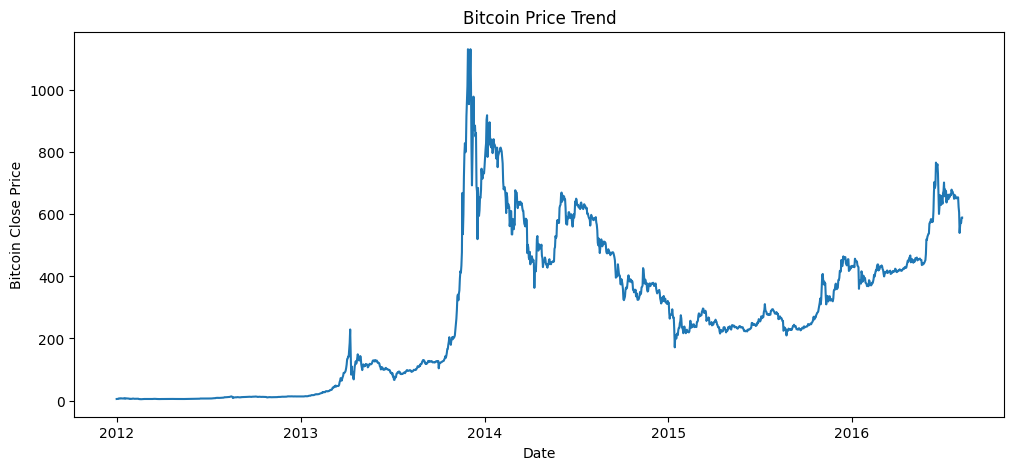

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_df.index,
    daily_df["Close"]
)

plt.xlabel("Date")
plt.ylabel("Bitcoin Close Price")
plt.title("Bitcoin Price Trend")

plt.show()

In [ ]:
# محاسبه بازده روزانه
daily_df["Return"] = daily_df["Close"].pct_change()

# نمایش چند ردیف اول
print(daily_df.head())

# آمار Return
print(daily_df["Return"].describe())

            Open  High   Low  Close      Volume    Return
Timestamp                                                
2012-01-01  4.58  5.00  4.58   5.00   21.602000       NaN
2012-01-02  5.00  5.00  5.00   5.00   19.048000  0.000000
2012-01-03  5.00  5.32  5.00   5.29   88.037281  0.058000
2012-01-04  5.29  5.57  4.93   5.57  107.233260  0.052930
2012-01-05  5.57  6.65  5.57   6.65   94.801829  0.193896
count    1680.000000
mean        0.004090
std         0.049374
min        -0.485185
25%        -0.011251
50%         0.001980
75%         0.018595
max         0.401420
Name: Return, dtype: float64


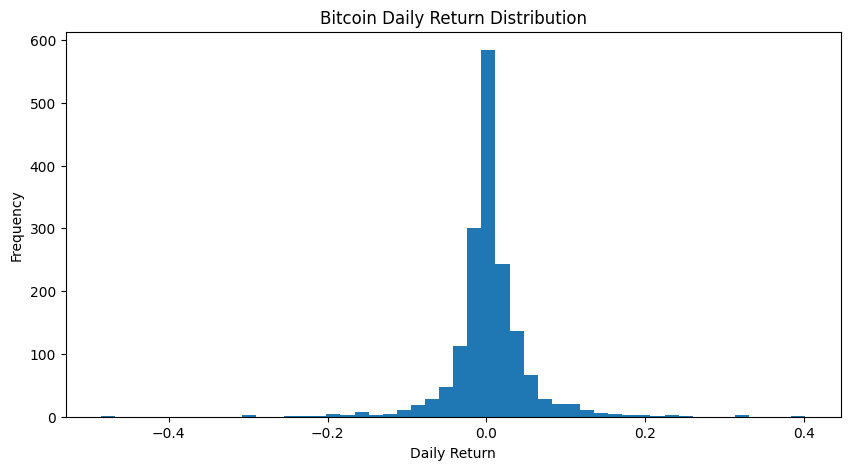

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    daily_df["Return"].dropna(),
    bins=50
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Bitcoin Daily Return Distribution")

plt.show()

              Open    High     Low   Close        Volume    Return  Volatility
Timestamp                                                                     
2016-08-03  540.00  572.34  521.00  563.42  15453.586160  0.043370    0.028506
2016-08-04  563.42  583.97  552.00  576.13   8499.836928  0.022559    0.028889
2016-08-05  578.14  578.20  562.00  572.50   4811.235839 -0.006301    0.028783
2016-08-06  572.98  592.00  562.56  589.48   6021.308789  0.029659    0.027908
2016-08-07  589.47  593.33  589.21  589.58    244.258121  0.000170    0.026815


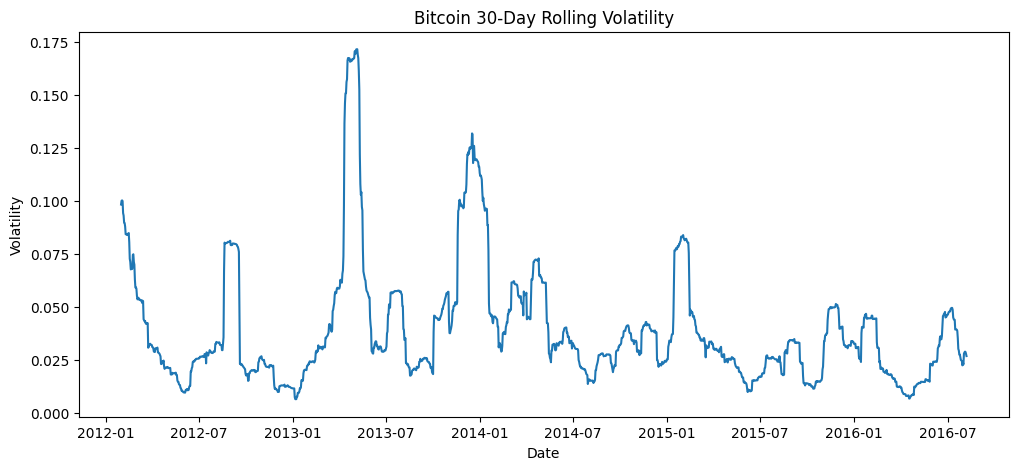

In [ ]:
# محاسبه نوسان 30 روزه
daily_df["Volatility"] = (
    daily_df["Return"]
    .rolling(window=30)
    .std()
)

# نمایش چند ردیف آخر
print(daily_df.tail())

# نمودار Volatility

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_df.index,
    daily_df["Volatility"]
)

plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Bitcoin 30-Day Rolling Volatility")

plt.show()

In [ ]:
# Lag 1 روز
daily_df["Close_Lag_1"] = daily_df["Close"].shift(1)

# Lag 7 روز
daily_df["Close_Lag_7"] = daily_df["Close"].shift(7)

# نمایش نتیجه
print(daily_df.head(10))

            Open  High   Low  Close      Volume    Return  Volatility  \
Timestamp                                                               
2012-01-01  4.58  5.00  4.58   5.00   21.602000       NaN         NaN   
2012-01-02  5.00  5.00  5.00   5.00   19.048000  0.000000         NaN   
2012-01-03  5.00  5.32  5.00   5.29   88.037281  0.058000         NaN   
2012-01-04  5.29  5.57  4.93   5.57  107.233260  0.052930         NaN   
2012-01-05  5.57  6.65  5.57   6.65   94.801829  0.193896         NaN   
2012-01-06  6.65  6.90  6.00   6.00   33.882747 -0.097744         NaN   
2012-01-07  6.00  6.80  6.00   6.80    0.295858  0.133333         NaN   
2012-01-08  6.80  7.00  6.80   7.00    5.000000  0.029412         NaN   
2012-01-09  7.00  7.00  6.23   6.30   66.869323 -0.100000         NaN   
2012-01-10  6.30  7.14  6.24   7.14   62.289980  0.133333         NaN   

            Close_Lag_1  Close_Lag_7  
Timestamp                             
2012-01-01          NaN          NaN  
2012-0

In [ ]:
# Moving Average 7 روزه
daily_df["MA_7"] = (
    daily_df["Close"]
    .rolling(window=7)
    .mean()
)

# Moving Average 30 روزه
daily_df["MA_30"] = (
    daily_df["Close"]
    .rolling(window=30)
    .mean()
)

# نمایش نتیجه
print(daily_df.head(35))

            Open  High   Low  Close      Volume    Return  Volatility  \
Timestamp                                                               
2012-01-01  4.58  5.00  4.58   5.00   21.602000       NaN         NaN   
2012-01-02  5.00  5.00  5.00   5.00   19.048000  0.000000         NaN   
2012-01-03  5.00  5.32  5.00   5.29   88.037281  0.058000         NaN   
2012-01-04  5.29  5.57  4.93   5.57  107.233260  0.052930         NaN   
2012-01-05  5.57  6.65  5.57   6.65   94.801829  0.193896         NaN   
2012-01-06  6.65  6.90  6.00   6.00   33.882747 -0.097744         NaN   
2012-01-07  6.00  6.80  6.00   6.80    0.295858  0.133333         NaN   
2012-01-08  6.80  7.00  6.80   7.00    5.000000  0.029412         NaN   
2012-01-09  7.00  7.00  6.23   6.30   66.869323 -0.100000         NaN   
2012-01-10  6.30  7.14  6.24   7.14   62.289980  0.133333         NaN   
2012-01-11  7.14  7.33  6.25   7.00  105.358934 -0.019608         NaN   
2012-01-12  7.00  7.38  6.51   6.51   82.301632 -0.

In [ ]:
# تغییر درصدی حجم معاملات نسبت به روز قبل
daily_df["Volume_Change"] = (
    daily_df["Volume"]
    .pct_change()
)

# نمایش نتیجه
print(daily_df.head(10))

# آمار Volume Change
print(daily_df["Volume_Change"].describe())

            Open  High   Low  Close      Volume    Return  Volatility  \
Timestamp                                                               
2012-01-01  4.58  5.00  4.58   5.00   21.602000       NaN         NaN   
2012-01-02  5.00  5.00  5.00   5.00   19.048000  0.000000         NaN   
2012-01-03  5.00  5.32  5.00   5.29   88.037281  0.058000         NaN   
2012-01-04  5.29  5.57  4.93   5.57  107.233260  0.052930         NaN   
2012-01-05  5.57  6.65  5.57   6.65   94.801829  0.193896         NaN   
2012-01-06  6.65  6.90  6.00   6.00   33.882747 -0.097744         NaN   
2012-01-07  6.00  6.80  6.00   6.80    0.295858  0.133333         NaN   
2012-01-08  6.80  7.00  6.80   7.00    5.000000  0.029412         NaN   
2012-01-09  7.00  7.00  6.23   6.30   66.869323 -0.100000         NaN   
2012-01-10  6.30  7.14  6.24   7.14   62.289980  0.133333         NaN   

            Close_Lag_1  Close_Lag_7      MA_7  MA_30  Volume_Change  
Timestamp                                           

In [24]:
# ساخت Target = قیمت Close روز بعد
daily_df["Target"] = daily_df["Close"].shift(-1)

# نمایش Featureها و Target
print(daily_df[[
    "Close",
    "Volume",
    "Return",
    "Volatility",
    "Close_Lag_1",
    "Close_Lag_7",
    "MA_7",
    "MA_30",
    "Volume_Change",
    "Target"
]].head(10))

            Close      Volume    Return  Volatility  Close_Lag_1  Close_Lag_7  \
Timestamp                                                                       
2012-01-01   5.00   21.602000       NaN         NaN          NaN          NaN   
2012-01-02   5.00   19.048000  0.000000         NaN         5.00          NaN   
2012-01-03   5.29   88.037281  0.058000         NaN         5.00          NaN   
2012-01-04   5.57  107.233260  0.052930         NaN         5.29          NaN   
2012-01-05   6.65   94.801829  0.193896         NaN         5.57          NaN   
2012-01-06   6.00   33.882747 -0.097744         NaN         6.65          NaN   
2012-01-07   6.80    0.295858  0.133333         NaN         6.00          NaN   
2012-01-08   7.00    5.000000  0.029412         NaN         6.80         5.00   
2012-01-09   6.30   66.869323 -0.100000         NaN         7.00         5.00   
2012-01-10   7.14   62.289980  0.133333         NaN         6.30         5.29   

                MA_7  MA_30

In [25]:
# حذف ردیف‌هایی که Feature یا Target ناقص دارند
model_df = daily_df.dropna()

# بررسی نتیجه
print(model_df.shape)

print(model_df.head())

(1648, 13)
            Open  High   Low  Close      Volume    Return  Volatility  \
Timestamp                                                               
2012-01-31  5.58  6.22  3.80   5.30  110.503333 -0.050179    0.098303   
2012-02-01  5.30  5.99  5.30   5.88   12.058806  0.109434    0.100066   
2012-02-02  5.88  6.28  5.88   6.28  251.000930  0.068027    0.100247   
2012-02-03  6.28  6.35  5.93   6.30  155.552453  0.003185    0.099933   
2012-02-04  6.30  6.50  5.94   5.94   67.634994 -0.057143    0.094257   

            Close_Lag_1  Close_Lag_7      MA_7     MA_30  Volume_Change  \
Timestamp                                                                 
2012-01-31         5.58         6.55  5.568571  6.276333       6.289138   
2012-02-01         5.30         6.31  5.507143  6.305667      -0.890874   
2012-02-02         5.88         5.50  5.618571  6.338667      19.814741   
2012-02-03         6.28         5.88  5.678571  6.363000      -0.380271   
2012-02-04         6.30    

In [26]:
# Feature ها
X = model_df[[
    "Close",
    "Volume",
    "Return",
    "Volatility",
    "Close_Lag_1",
    "Close_Lag_7",
    "MA_7",
    "MA_30",
    "Volume_Change"
]]

# Target
y = model_df["Target"]

# بررسی اندازه
print(X.shape)
print(y.shape)

(1648, 9)
(1648,)


In [27]:
# تعیین نقطه تقسیم
split_index = int(len(model_df) * 0.8)

# تقسیم زمانی
train = model_df.iloc[:split_index]
test = model_df.iloc[split_index:]

# جدا کردن X و y

X_train = train[[
    "Close",
    "Volume",
    "Return",
    "Volatility",
    "Close_Lag_1",
    "Close_Lag_7",
    "MA_7",
    "MA_30",
    "Volume_Change"
]]

y_train = train["Target"]


X_test = test[[
    "Close",
    "Volume",
    "Return",
    "Volatility",
    "Close_Lag_1",
    "Close_Lag_7",
    "MA_7",
    "MA_30",
    "Volume_Change"
]]

y_test = test["Target"]


print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1318, 9)
Test: (330, 9)


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# پیش‌بینی ساده:
# فردا = امروز
baseline_prediction = X_test["Close"]

# MAE
mae_baseline = mean_absolute_error(
    y_test,
    baseline_prediction
)

# RMSE
rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

# MAPE
mape_baseline = np.mean(
    np.abs(
        (y_test - baseline_prediction) / y_test
    )
) * 100


print("Baseline Results")
print("----------------")
print("MAE :", mae_baseline)
print("RMSE:", rmse_baseline)
print("MAPE:", mape_baseline)

Baseline Results
----------------
MAE : 8.854999999999999
RMSE: 14.98756364254691
MAPE: 1.9468311464717973


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ساخت مدل
lr_model = LinearRegression()

# آموزش مدل با داده‌های گذشته
lr_model.fit(
    X_train,
    y_train
)

# پیش‌بینی روی داده‌های آینده
lr_prediction = lr_model.predict(
    X_test
)

# ارزیابی مدل

mae_lr = mean_absolute_error(
    y_test,
    lr_prediction
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        lr_prediction
    )
)

mape_lr = np.mean(
    np.abs(
        (y_test - lr_prediction) / y_test
    )
) * 100


print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("MAPE:", mape_lr)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [30]:
import numpy as np

# بررسی مقدارهای infinity
print(np.isinf(X_train).sum())

# نمایش ردیف‌هایی که infinity دارند
print(X_train[np.isinf(X_train).any(axis=1)])

Close            0
Volume           0
Return           0
Volatility       0
Close_Lag_1      0
Close_Lag_7      0
MA_7             0
MA_30            0
Volume_Change    1
dtype: int64
             Close       Volume   Return  Volatility  Close_Lag_1  \
Timestamp                                                           
2015-01-09  293.97  9914.249594  0.06203    0.035607        276.8   

            Close_Lag_7        MA_7    MA_30  Volume_Change  
Timestamp                                                    
2015-01-09       315.42  278.167143  316.248            inf  


In [31]:
import numpy as np

# تبدیل infinity به NaN
model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# حذف ردیف‌های مشکل‌دار
model_df = model_df.dropna()

# دوباره X و y را بسازیم

X = model_df[[
    "Close",
    "Volume",
    "Return",
    "Volatility",
    "Close_Lag_1",
    "Close_Lag_7",
    "MA_7",
    "MA_30",
    "Volume_Change"
]]

y = model_df["Target"]

print(model_df.shape)
print(X.isnull().sum())

(1647, 13)
Close            0
Volume           0
Return           0
Volatility       0
Close_Lag_1      0
Close_Lag_7      0
MA_7             0
MA_30            0
Volume_Change    0
dtype: int64


In [32]:
# پیدا کردن نقطه تقسیم 80/20
split_index = int(len(model_df) * 0.8)

# تقسیم زمانی
train = model_df.iloc[:split_index]
test = model_df.iloc[split_index:]


features = [
    "Close",
    "Volume",
    "Return",
    "Volatility",
    "Close_Lag_1",
    "Close_Lag_7",
    "MA_7",
    "MA_30",
    "Volume_Change"
]


X_train = train[features]
y_train = train["Target"]

X_test = test[features]
y_test = test["Target"]


print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1317, 9)
Test: (330, 9)


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ساخت مدل
lr_model = LinearRegression()

# آموزش
lr_model.fit(
    X_train,
    y_train
)

# پیش‌بینی
lr_prediction = lr_model.predict(
    X_test
)

# ارزیابی
mae_lr = mean_absolute_error(
    y_test,
    lr_prediction
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        lr_prediction
    )
)

mape_lr = np.mean(
    np.abs(
        (y_test - lr_prediction) / y_test
    )
) * 100


print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("MAPE:", mape_lr)

Linear Regression Results
-------------------------
MAE : 9.729996237021775
RMSE: 15.57784949287372
MAPE: 2.146422572850858


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ساخت مدل
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# آموزش
rf_model.fit(
    X_train,
    y_train
)

# پیش‌بینی
rf_prediction = rf_model.predict(
    X_test
)

# ارزیابی

mae_rf = mean_absolute_error(
    y_test,
    rf_prediction
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

mape_rf = np.mean(
    np.abs(
        (y_test - rf_prediction) / y_test
    )
) * 100


print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf)

Random Forest Results
---------------------
MAE : 13.832674242424263
RMSE: 20.451096431294136
MAPE: 2.967832261282477


In [35]:
!pip install xgboost

In [36]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ساخت مدل
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)


# آموزش
xgb_model.fit(
    X_train,
    y_train
)


# پیش‌بینی
xgb_prediction = xgb_model.predict(
    X_test
)


# ارزیابی

mae_xgb = mean_absolute_error(
    y_test,
    xgb_prediction
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_prediction
    )
)

mape_xgb = np.mean(
    np.abs(
        (y_test - xgb_prediction) / y_test
    )
) * 100


print("XGBoost Results")
print("----------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb)

XGBoost Results
----------------
MAE : 14.374229334975734
RMSE: 21.111989975940602
MAPE: 3.122933509907043


In [37]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae_baseline,
        mae_lr,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_baseline,
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],

    "MAPE": [
        mape_baseline,
        mape_lr,
        mape_rf,
        mape_xgb
    ]
})


print(results)

               Model        MAE       RMSE      MAPE
0           Baseline   8.855000  14.987564  1.946831
1  Linear Regression   9.729996  15.577849  2.146423
2      Random Forest  13.832674  20.451096  2.967832
3            XGBoost  14.374229  21.111990  3.122934


In [38]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print(feature_importance)

         Feature  Importance
0          Close    0.908596
4    Close_Lag_1    0.033357
6           MA_7    0.028434
7          MA_30    0.019564
5    Close_Lag_7    0.004494
3     Volatility    0.003155
2         Return    0.001088
8  Volume_Change    0.000669
1         Volume    0.000642


In [39]:
# سری قیمت بسته شدن

close_series = daily_df["Close"]


# تقسیم زمانی 80/20

split_index = int(len(close_series)*0.8)

train_arima = close_series.iloc[:split_index]

test_arima = close_series.iloc[split_index:]


print(train_arima.shape)
print(test_arima.shape)

(1344,)
(337,)


In [40]:
from statsmodels.tsa.stattools import adfuller

# تست ایستایی روی قیمت خام
adf_result = adfuller(train_arima)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -1.6287109581406018
p-value: 0.4681655211426517


/tmp/ipykernel_7081/1037908214.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(train_arima)


In [41]:
# تفاضل یک مرتبه‌ای
train_diff = train_arima.diff().dropna()

print(train_diff.head())

Timestamp
2012-01-02    0.00
2012-01-03    0.29
2012-01-04    0.28
2012-01-05    1.08
2012-01-06   -0.65
Freq: D, Name: Close, dtype: float64


In [42]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train_diff)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -9.053553064057411
p-value: 4.7681098706786524e-15


/tmp/ipykernel_7081/3715065108.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(train_diff)


In [43]:
from statsmodels.tsa.arima.model import ARIMA

# ساخت مدل
arima_model = ARIMA(
    train_arima,
    order=(1,1,1)
)

# آموزش
arima_result = arima_model.fit()

# خلاصه مدل
print(arima_result.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1344
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5979.980
Date:                Wed, 23 Sep 2026   AIC                          11965.959
Time:                        15:40:41   BIC                          11981.567
Sample:                    01-01-2012   HQIC                         11971.806
                         - 09-05-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4689      0.136      3.437      0.001       0.201       0.736
ma.L1         -0.5060      0.133     -3.803      0.000      -0.767      -0.245
sigma2       431.6146      4.109    105.046      0.0

In [44]:
arima_prediction = arima_result.forecast(
    steps=len(test_arima)
)

print(arima_prediction.head())

2015-09-06    235.366318
2015-09-07    235.256752
2015-09-08    235.205380
2015-09-09    235.181294
2015-09-10    235.170000
Freq: D, Name: predicted_mean, dtype: float64


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae_arima = mean_absolute_error(
    test_arima,
    arima_prediction
)

# RMSE
rmse_arima = np.sqrt(
    mean_squared_error(
        test_arima,
        arima_prediction
    )
)

# MAPE
mape_arima = np.mean(
    np.abs(
        (test_arima - arima_prediction) / test_arima
    )
) * 100


print("ARIMA Results")
print("----------------")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)

ARIMA Results
----------------
MAE : 198.5997044699013
RMSE: 235.8375031686416
MAPE: 40.813732659414576


In [46]:
# ساخت Return

returns = daily_df["Close"].pct_change().dropna()

print(returns.head())
print(returns.describe())

Timestamp
2012-01-02    0.000000
2012-01-03    0.058000
2012-01-04    0.052930
2012-01-05    0.193896
2012-01-06   -0.097744
Freq: D, Name: Close, dtype: float64
count    1680.000000
mean        0.004090
std         0.049374
min        -0.485185
25%        -0.011251
50%         0.001980
75%         0.018595
max         0.401420
Name: Close, dtype: float64


In [47]:
split_index = int(len(returns)*0.8)

train_returns = returns.iloc[:split_index]
test_returns = returns.iloc[split_index:]


print(train_returns.shape)
print(test_returns.shape)

(1344,)
(336,)


In [48]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 11.8 MB/s eta 0:00:00


In [49]:
from arch import arch_model

# ساخت GARCH(1,1)

garch_model = arch_model(
    train_returns,
    vol="Garch",
    p=1,
    q=1
)

garch_result = garch_model.fit()

print(garch_result.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 168473072.0327147
Iteration:      2,   Func. Count:     19,   Neg. LLF: 20269597.442862276
Iteration:      3,   Func. Count:     31,   Neg. LLF: 35984.2017727606
Iteration:      4,   Func. Count:     42,   Neg. LLF: 232932672.4438528
Iteration:      5,   Func. Count:     54,   Neg. LLF: 21552482.76406206
Optimization terminated successfully    (Exit mode 0)
            Current function value: -2437.6650874583856
            Iterations: 7
            Function evaluations: 64
            Gradient evaluations: 5
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                2437.67
Distribution:                  Normal   AIC:                          -4867.33
Method:            Maximum Likelihoo

/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002811. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [51]:
# پیش‌بینی volatility برای دوره تست

garch_forecast = garch_result.forecast(
    horizon=len(test_returns)
)

# گرفتن variance پیش‌بینی‌شده
predicted_variance = garch_forecast.variance.iloc[-1]

# تبدیل variance به volatility
predicted_volatility = np.sqrt(predicted_variance)


print(predicted_volatility.head())

h.001    0.024055
h.002    0.024973
h.003    0.025841
h.004    0.026665
h.005    0.027448
Name: 2015-09-06 00:00:00, dtype: float64


In [52]:
# volatility واقعی از return های تست

realized_volatility = test_returns.std()


print("Realized Volatility:")
print(realized_volatility)

Realized Volatility:
0.030649726578433005


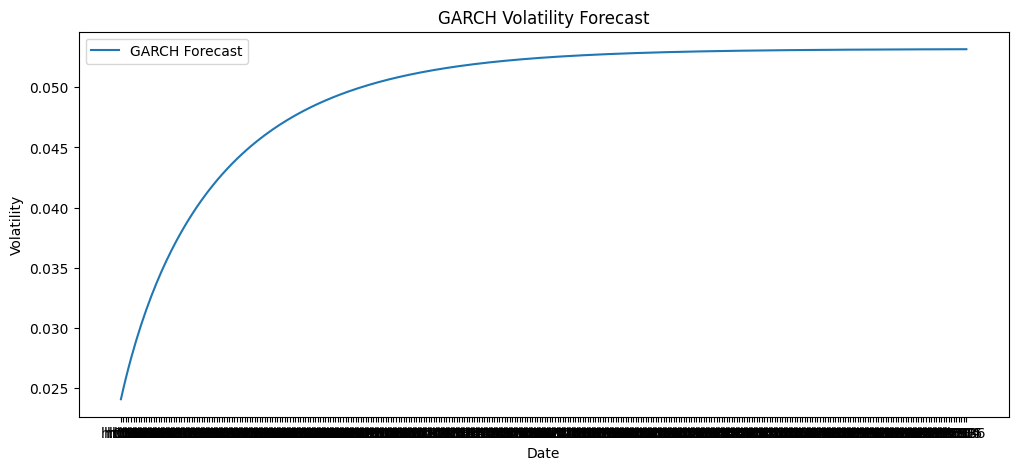

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    predicted_volatility.index,
    predicted_volatility,
    label="GARCH Forecast"
)

plt.title("GARCH Volatility Forecast")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.show()

In [54]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "ARIMA"
    ],

    "MAE": [
        mae_baseline,
        mae_lr,
        mae_rf,
        mae_xgb,
        mae_arima
    ],

    "RMSE": [
        rmse_baseline,
        rmse_lr,
        rmse_rf,
        rmse_xgb,
        rmse_arima
    ],

    "MAPE": [
        mape_baseline,
        mape_lr,
        mape_rf,
        mape_xgb,
        mape_arima
    ]
})


print(final_results)

               Model         MAE        RMSE       MAPE
0           Baseline    8.855000   14.987564   1.946831
1  Linear Regression    9.729996   15.577849   2.146423
2      Random Forest   13.832674   20.451096   2.967832
3            XGBoost   14.374229   21.111990   3.122934
4              ARIMA  198.599704  235.837503  40.813733
